In [1]:
import sys
sys.path.append('../')
# from experiments import utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pypolo2
import os
current_dir = os.getcwd()

# Environment -- PINNS

In [2]:
Setting = pypolo2.utilities.Config()
strategy_name = ["DualObjectScheduling",
                 "MaximumCoverageSpray",
                 "NonmyonicLatticeSpray",
                 "SATRACT",
                 "NoSpray",
                 ]
comparing_variables = [["teamsize_1","teamsize_2","teamsize_3","teamsize_4","teamsize_5"],
                       ["numsource_1","numsource_2","numsource_3","numsource_4","numsource_5"]]
# seeds1 = [7,11,18,20,36]
seeds1 = [7,11,18,20]
seeds2 = [7,11,18,20]
team_sizes = [1,2,3,4,5]
sourcenums = [1,2,3,4,5]

# Average Pollution Concentration

In [3]:
# 区域平均pm2.5浓度,所有实验的平均值
strategy_meanpollution = []
# teamsize
sche_step = 0
adaptive_step = 0
alpha = 1.6
for strategy in strategy_name:
    if strategy == "NonmyonicLatticeSpray":
        sche_step = 12
        adaptive_step = 4
    else:
        sche_step = 12
        adaptive_step = 3
    variable_meanpollution = []
    for i in range(5):
        comparing_variable = comparing_variables[0][i]
        team_size = team_sizes[i]
        sourcenum = 2
        seed_meanpollution = []
        for seed in seeds1:
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_meanpollution = []
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            seed_meanpollution.append(np.mean(time_meanpollution))
        variable_meanpollution.append(np.mean(seed_meanpollution))
        
    # numsource
    for i in range(5):
        comparing_variable = comparing_variables[1][i]
        team_size = 4
        sourcenum = sourcenums[i]
        seed_sumsprayeffect = []
        for seed in seeds2:
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            seed_meanpollution.append(np.mean(time_meanpollution))
        variable_meanpollution.append(np.mean(seed_meanpollution))
        
    strategy_meanpollution.append(np.mean(variable_meanpollution))
print(strategy_meanpollution)

[32.16371145832131, 36.746696954440296, 35.68904024329828, 38.03418342904168, 78.17411546994416]


In [4]:
# 计算标准差。标准误
# 首先生成样本列表
data_process = {}
for strategy in strategy_name:
    # 参数配置
    if strategy == "NonmyonicLatticeSpray":
        sche_step = 12
        adaptive_step = 4
    else:
        sche_step = 12
        adaptive_step = 3
    seed_meanpollution = []
    for seed in seeds1:
        variable_meanpollution = []
        # team_size
        for i in range(5):
            comparing_variable = comparing_variables[0][i]
            team_size = team_sizes[i]
            sourcenum = 2
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            time_meanpollution = []
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            variable_meanpollution.append(np.mean(time_meanpollution))
        # numsource
        for i in range(5):
            comparing_variable = comparing_variables[1][i]
            team_size = 4
            sourcenum = sourcenums[i]
            pklname = f'SEED_{seed}_VS{team_size}_TS{Setting.max_num_samples}_SS{sche_step}_AS{adaptive_step}_SN{sourcenum}_RS{Setting.replenish_speed}_WV{Setting.water_volume}_ALPHA{alpha}.pkl'
            pkldir = os.path.join(current_dir,"outputs", strategy, comparing_variable, pklname)
            data = pypolo2.experiments.utilities.readpkl(pkldir)
            for i in range(48):
                if i >= 24:
                    mean_env = np.mean(data['truth_env'][i])
                    time_meanpollution.append(mean_env)
            variable_meanpollution.append(np.mean(time_meanpollution))
        seed_meanpollution.append(np.mean(variable_meanpollution))

    data_process[strategy] = seed_meanpollution
print(data_process)
            

{'DualObjectScheduling': [33.07709075065768, 32.13269985267563, 36.81181604393637, 35.59534501601041], 'MaximumCoverageSpray': [43.147386476887434, 34.57230077449131, 38.452995834651915, 40.331553172130626], 'NonmyonicLatticeSpray': [41.5295664433976, 29.143886861685722, 45.99774942852853, 40.90204942824938], 'SATRACT': [48.34106744928496, 32.491393903630666, 42.85983262387811, 37.657040914442085], 'NoSpray': [82.43833847586373, 88.74657406144777, 79.24105808340342, 88.78925092450496]}


In [5]:
import plotly.graph_objects as go
import numpy as np

width = 1000
height = 666
colors_dict = ['#3D9182','#C74223','#245C8F', '#FF8C00']

xtitle = 'Sprinkle Strategy'
ytitle = 'Average Suppression of PM2.5(μg/m³)'
# 创建箱线图
fig = go.Figure()

# 按原始顺序添加箱线图
strategies = ['NoSpray', 'MaximumCoverageSpray', 'NonmyonicLatticeSpray', 'SATRACT', 'DualObjectScheduling']
for idx, strategy in enumerate(strategies):
    fig.add_trace(go.Box(
        y=data_process[strategy],
        name=strategy.replace('NoSpray', 'WithoutSprinkle')
                     .replace('MaximumCoverageSpray', 'MCS')
                     .replace('NonmyonicLatticeSpray', 'SoScheduler')
                     .replace('SATRACT','TRACT')
                     .replace('DualObjectScheduling', 'Ours'),
        marker_color=colors_dict[idx % len(colors_dict)],
        boxmean=True,  # 显示均值线
        # boxpoints='all',  # 显示所有数据点
        jitter=0.3,  # 点分布程度
        pointpos=0,  # 点水平位置
        line_width=2,  # 箱线宽度
        width=0.5  # 箱体宽度
    ))

# 在原有箱线图代码基础上修改布局配置
fig.update_layout(
    title=None,
    xaxis_title=xtitle,
    yaxis_title=ytitle,
    yaxis_range=[20, 100],
    showlegend=False,
    # 新增背景设置
    plot_bgcolor='white',  # 绘图区背景
    paper_bgcolor='white', # 整个画布背景
    # 调整坐标轴网格线
    xaxis=dict(
        showgrid=True,  # 关闭x轴网格线
        gridcolor='rgba(200,200,200,0.8)',  # 浅灰色网格线
        griddash='dot',          # 虚线样式：点状虚线
        linecolor='black',  # 坐标轴线颜色
        mirror=True,
        linewidth=3
    ),
    yaxis=dict(
        showgrid=True,    # 保持y轴网格线
        gridcolor='rgba(200,200,200,0.8)',  # 浅灰色网格线
        griddash='dot',          # 虚线样式：点状虚线
        linecolor='black',
        mirror=True,
        linewidth=3
    ),
    width=width,
    height=height,
    boxmode='group',
    font=dict(
        family="Arial",
        size=30,
        color="black"
    )
)

# 输出图像
filename = './outputs/png/Boxplot_SchedulingPerformance2.png'
fig.write_image(filename, scale=1)
print(f"Saved to: {filename}")
fig.show()

Saved to: ./outputs/png/Boxplot_SchedulingPerformance2.png


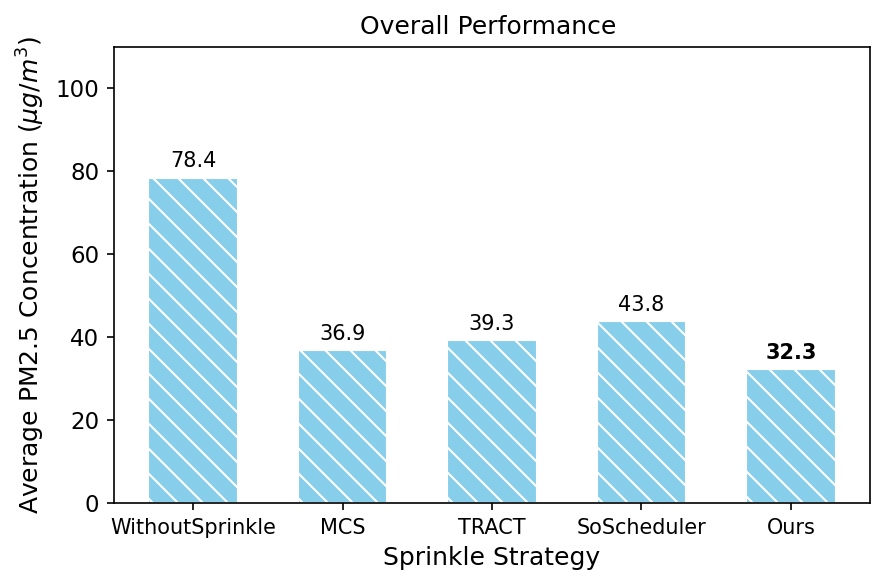

In [22]:
# 加一张图，只画颗粒物浓度
import matplotlib.pyplot as plt
import numpy as np

# Data

models = ['WithoutSprinkle','MCS', 'TRACT', 'SoScheduler',  'Ours']
Average_Concentration = [78.4, 36.9, 39.3, 43.8,  32.3]

x = np.arange(len(models))  
width = 0.6

fig, ax = plt.subplots(figsize =(6,4),dpi=150)
pm25_hatch = '//'
pm10_hatch = '\\\\'
edge_color = 'white'

for i in range(len(models)):
    ax.bar(x[i] + width/2, Average_Concentration[i], width, label='PM2.5 Average Concentration (μg/m³)' if i == 0 else "",
           color='skyblue', hatch=pm10_hatch, edgecolor=edge_color)

ax.set_ylabel('Average PM2.5 Concentration ($\mu{g}/m^3$)', fontsize=12)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel('Sprinkle Strategy', fontsize=12)
ax.set_title('Overall Performance ')
ax.set_xticks(x+width/2)
ax.set_ylim([0, 110])
ax.set_xticklabels(models)

# 去掉标题
# ax.set_title('')

# 将图例放置在上方
# ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

def autolabel(values, offset):
    for i, value in enumerate(values):
        fontweight = 'bold' if models[i] == 'Ours' else 'normal'
        ax.annotate('{}'.format(value),
                    xy=(x[i] + offset, value),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight=fontweight)

autolabel(Average_Concentration, width/2)

fig.tight_layout()
filename = './outputs/png/Overall_SchedulingPerformance2.png'
plt.savefig(filename,bbox_inches = 'tight')
